<a href="https://colab.research.google.com/github/andreslill/mosquito-season-suitability/blob/main/notebooks/methodology_and_validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Methodology & Validation: Mosquito Suitability Model

This notebook documents the methodology, external validation, and limitations of the mosquito climate suitability model. Sections 1–14 validate suitability scores against occurrence records from Kraemer et al. (2015).
Sections 15–24 cover comparison with independent transmission models, photoperiod parameter validation, confirmed European distribution, model limitations, potential extensions, and references.

## Validation

**Approach:**
1. Aggregate monthly suitability scores to city-level metrics (peak month, season length, mean active-month score)
2. Spatial join: for each city, check whether any Kraemer occurrence falls within a given radius
3. Compare score distributions between presence and absence groups
4. Quantify discrimination with ROC/AUC

**Data:**
- `mosquito_suitability.csv`: 1,423 cities × 12 months, ERA5 1991–2020 climate normals
- `kraemer_occurrences.csv`: 42,066 occurrence records, 1958–2014, both species

**Model components:** Core functions (Magnus approximation, sigmoid PhotoFactor) are validated with unit tests in `mosquito_suitability_pipeline.ipynb`.

**Key limitation:** Kraemer records go up to 2014; suitability scores are based on 1991–2020 climate normals. This temporal mismatch has a directional consequence for *Ae. albopictus* specifically: the species substantially expanded into new European regions between 2014 and 2020, meaning cities established in that window appear as absence in the validation layer despite being climatically suitable. A temporal robustness check in Section 12 restricts the spatial join to pre-2014 records only and compares AUC against the full-dataset result. AUC is stable between the two subsets for both species (Δ = +0.02 for Ae. aegypti, 0.00 for Ae. albopictus), confirming that post-2014 range expansion does not materially inflate the validation result. For Ae. aegypti, whose global range was largely stable over this period, the mismatch is even less consequential.

### 1. Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.spatial import cKDTree
from sklearn.metrics import roc_curve, auc
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# Plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'

RADIUS_KM = 50  # matching radius for spatial join
EARTH_RADIUS_KM = 6371.0

print('Libraries loaded.')

Libraries loaded.


### 2. Load Data

`mosquito_suitability.csv` is the direct output of `mosquito_suitability_pipeline.ipynb`.
`kraemer_occurrences.csv` was derived from the raw Kraemer et al. (2015/2017) dataset —
see the commented preprocessing cell below. Both files are included in the repository
and can be loaded directly.

For `kraemer_occurrences.csv`, the harmonization steps were:
- Column renaming: `VECTOR` → `species`, `Y`/`X` → `lat`/`lon`, `COUNTRY` → `country_name`, `COUNTRY_ID` → `iso3`
- Species label standardization: `'Aedes aegypti'` → `'Ae. aegypti'`, `'Aedes albopictus'` → `'Ae. albopictus'`
- Addition of `is_point` flag: `True` where `location_type == 'point'`, `False` for polygon centroids
- Rows without coordinates dropped; `year` cast to nullable integer

The `is_point` flag is used in Section 3 to restrict the spatial join to point-level records only, excluding polygon centroids that may represent regions up to hundreds of km wide.

In [3]:
# KRAEMER PREPROCESSING
# This cell documents how kraemer_occurrences.csv was derived from the raw
# Kraemer et al. (2015/2017) dataset. The processed file is already included
# in the repository — this cell does not need to be run.
#
# Raw source: aegypti_albopictus.csv (Kraemer et al. 2015/2017, Dryad)
# https://doi.org/10.5061/dryad.47v3c

# import pandas as pd
#
# kraemer_raw = pd.read_csv("aegypti_albopictus.csv")
#
# kraemer = pd.DataFrame({
#     "species":       kraemer_raw["VECTOR"],
#     "lat":           kraemer_raw["Y"],
#     "lon":           kraemer_raw["X"],
#     "year":          kraemer_raw["YEAR"],
#     "country_name":  kraemer_raw["COUNTRY"],
#     "iso3":          kraemer_raw["COUNTRY_ID"],
#     "location_type": kraemer_raw["LOCATION_TYPE"],
#     "source":        "Kraemer et al. 2015/2017",
# })
#
# SPECIES_MAP = {
#     "Aedes aegypti":    "Ae. aegypti",
#     "Aedes albopictus": "Ae. albopictus",
# }
# kraemer["species"] = kraemer["species"].map(SPECIES_MAP).fillna(kraemer["species"])
# kraemer["is_point"] = kraemer["location_type"] == "point"
# kraemer = kraemer.dropna(subset=["lat", "lon"])
# kraemer["year"] = pd.to_numeric(kraemer["year"], errors="coerce").astype("Int64")
#
# kraemer.to_csv("kraemer_occurrences.csv", index=False)

In [5]:
# Load suitability data
suit    = pd.read_csv('mosquito_suitability.csv')
kraemer = pd.read_csv('kraemer_occurrences.csv')

print(f'Suitability: {len(suit):,}  ({suit["city"].nunique()} cities)')
print(f'Kraemer records:         {len(kraemer):,}')
print()
print('Kraemer species breakdown:')
print(kraemer['species'].value_counts())
print()
print('Kraemer location_type breakdown:')
print(kraemer['location_type'].value_counts())


Suitability: 17,076  (1418 cities)
Kraemer records:         42,066

Kraemer species breakdown:
species
Ae. albopictus    22137
Ae. aegypti       19929
Name: count, dtype: int64

Kraemer location_type breakdown:
location_type
point               31271
polygon              9558
Less than 25km        248
Less than 100km       246
Less than 10km        190
Less than 10 km        45
Less than 100 km       18
Less than 25 km        10
Name: count, dtype: int64


### 3. Aggregate Suitability to City Level

From 12 monthly rows per city, derive city-level metrics per species:
- **`peak_score`**: maximum monthly suitability (best-month performance)
- **`season_months_02/03/04`**: number of months exceeding a suitability threshold of 0.2, 0.3, or 0.4 respectively. A threshold of `> 0` was deliberately avoided: for a multiplicative score, values just above zero can reflect negligible climatic suitability while still being counted as active months, which distorts season length. The three thresholds span a range from permissive to strict. Testing all three confirms that the main conclusions do not depend on any single cutpoint, which is the relevant methodological safeguard against threshold sensitivity.
- **`mean_active_score`**: mean suitability across months with score >= 0.2 (the lowest threshold tested).


In [6]:
def city_metrics(df, species_col):
    """Aggregate monthly scores to city-level metrics."""
    grp = df.groupby(['city', 'country', 'lat', 'lon'])
    peak = grp[species_col].max().rename('peak_score')
    season_02 = (df[species_col] >= 0.2).groupby(
        [df['city'], df['country'], df['lat'], df['lon']]
    ).sum().rename('season_months_02')
    season_03 = (df[species_col] >= 0.3).groupby(
        [df['city'], df['country'], df['lat'], df['lon']]
    ).sum().rename('season_months_03')
    season_04 = (df[species_col] >= 0.4).groupby(
        [df['city'], df['country'], df['lat'], df['lon']]
    ).sum().rename('season_months_04')
    mean_active = df[df[species_col] >= 0.2].groupby(
        ['city', 'country', 'lat', 'lon']
    )[species_col].mean().rename('mean_active_score')
    result = pd.concat([peak, season_02, season_03, season_04, mean_active], axis=1).reset_index()
    result['mean_active_score'] = result['mean_active_score'].fillna(0)
    return result

cities_aeg = city_metrics(suit, 'suitability_score_aegypti')
cities_alb = city_metrics(suit, 'suitability_score_albopictus')

print('Ae. albopictus city metrics:')
print(cities_alb[['peak_score','season_months_02','season_months_03','season_months_04']].describe().round(3))


Ae. albopictus city metrics:
       peak_score  season_months_02  season_months_03  season_months_04
count    1423.000          1423.000          1423.000          1423.000
mean        0.798             6.342             5.918             5.445
std         0.193             3.714             3.680             3.689
min         0.000             0.000             0.000             0.000
25%         0.688             4.000             4.000             3.000
50%         0.869             4.000             4.000             4.000
75%         0.943            11.000             9.000             8.000
max         1.000            12.000            12.000            12.000


### 4. Spatial Join: Assign Presence/Absence Labels

For each city, check whether any Kraemer occurrence record falls within `RADIUS_KM`.

**Design choices:**
- Only `is_point == True` records are used. Polygon centroids can represent regions hundreds of km wide, which would introduce false positives at city level.
- Both species are handled separately.
- The join is done with a 3D unit-sphere kd-tree (fast, accurate for any lat/lon range).

In [7]:
def latlon_to_xyz(lat_deg, lon_deg):
    """Convert lat/lon (degrees) to unit-sphere XYZ."""
    lat = np.radians(lat_deg)
    lon = np.radians(lon_deg)
    x = np.cos(lat) * np.cos(lon)
    y = np.cos(lat) * np.sin(lon)
    z = np.sin(lat)
    return np.column_stack([x, y, z])

def spatial_presence_labels(city_df, occ_df, radius_km=50):
    """
    For each city in city_df, assign presence=1 if any occurrence in occ_df
    falls within radius_km. Uses cKDTree on unit sphere.
    """
    # chord length threshold on unit sphere
    chord_threshold = 2 * np.sin(np.radians(radius_km / EARTH_RADIUS_KM / 2))

    city_xyz = latlon_to_xyz(city_df['lat'].values, city_df['lon'].values)
    occ_xyz  = latlon_to_xyz(occ_df['lat'].values, occ_df['lon'].values)

    tree = cKDTree(occ_xyz)
    dist, _ = tree.query(city_xyz, k=1)

    presence = (dist <= chord_threshold).astype(int)
    return presence

# Filter to point-only records per species
k_aeg = kraemer[(kraemer['species'] == 'Ae. aegypti') & (kraemer['is_point'] == True)].dropna(subset=['lat','lon'])
k_alb = kraemer[(kraemer['species'] == 'Ae. albopictus') & (kraemer['is_point'] == True)].dropna(subset=['lat','lon'])

print(f'Kraemer point records used: Ae. aegypti: {len(k_aeg):,} | Ae. albopictus: {len(k_alb):,}')

cities_aeg['presence'] = spatial_presence_labels(cities_aeg, k_aeg, radius_km=RADIUS_KM)
cities_alb['presence'] = spatial_presence_labels(cities_alb, k_alb, radius_km=RADIUS_KM)

for label, df in [('Ae. aegypti', cities_aeg), ('Ae. albopictus', cities_alb)]:
    n1 = df['presence'].sum()
    n0 = len(df) - n1
    print(f'{label}: {n1} presence cities, {n0} absence cities  ({100*n1/len(df):.1f}% presence rate)')


Kraemer point records used: Ae. aegypti: 13,991 | Ae. albopictus: 17,280
Ae. aegypti: 71 presence cities, 1352 absence cities  (5.0% presence rate)
Ae. albopictus: 23 presence cities, 1400 absence cities  (1.6% presence rate)


### 5. Sensitivity Analysis: Radius Choice

The 50 km radius is a modelling decision. The table below shows how both presence rate and AUC (for `season_months_02`, the strongest discriminator) change across radii. Stable AUC across radii indicates that the main conclusions do not hinge on the choice of 50 km.

In [8]:
radii = [25, 50, 75, 100, 150]
results = []
for r in radii:
    for label, city_df, occ_df in [('Ae. aegypti', cities_aeg, k_aeg), ('Ae. albopictus', cities_alb, k_alb)]:
        pres_labels = spatial_presence_labels(city_df, occ_df, radius_km=r)
        n_pres = pres_labels.sum()
        # AUC for season_months_02 at this radius
        tmp = city_df.copy()
        tmp['presence'] = pres_labels
        if tmp['presence'].sum() > 0:
            fpr, tpr, _ = roc_curve(tmp['presence'], tmp['season_months_02'])
            roc_auc = round(auc(fpr, tpr), 3)
        else:
            roc_auc = None
        results.append({'radius_km': r, 'species': label,
                        'n_presence': n_pres,
                        'pct_presence': round(100*n_pres/len(city_df), 1),
                        'AUC_season_02': roc_auc})

print(pd.DataFrame(results).to_string(index=False))

 radius_km        species  n_presence  pct_presence  AUC_season_02
        25    Ae. aegypti          28           2.0          0.799
        25 Ae. albopictus           7           0.5          0.609
        50    Ae. aegypti          71           5.0          0.835
        50 Ae. albopictus          23           1.6          0.736
        75    Ae. aegypti         109           7.7          0.844
        75 Ae. albopictus          39           2.7          0.741
       100    Ae. aegypti         136           9.6          0.848
       100 Ae. albopictus          52           3.7          0.699
       150    Ae. aegypti         167          11.7          0.851
       150 Ae. albopictus          82           5.8          0.713


### 6. Distribution Comparison: Presence vs. Absence-Labelled Cities

Visualise and test whether suitability scores differ between presence-labelled and absence-labelled cities. Note that absence-labelled here means no Kraemer point record within 50 km, not confirmed biological absence. The negative class is noisy and should be interpreted accordingly.

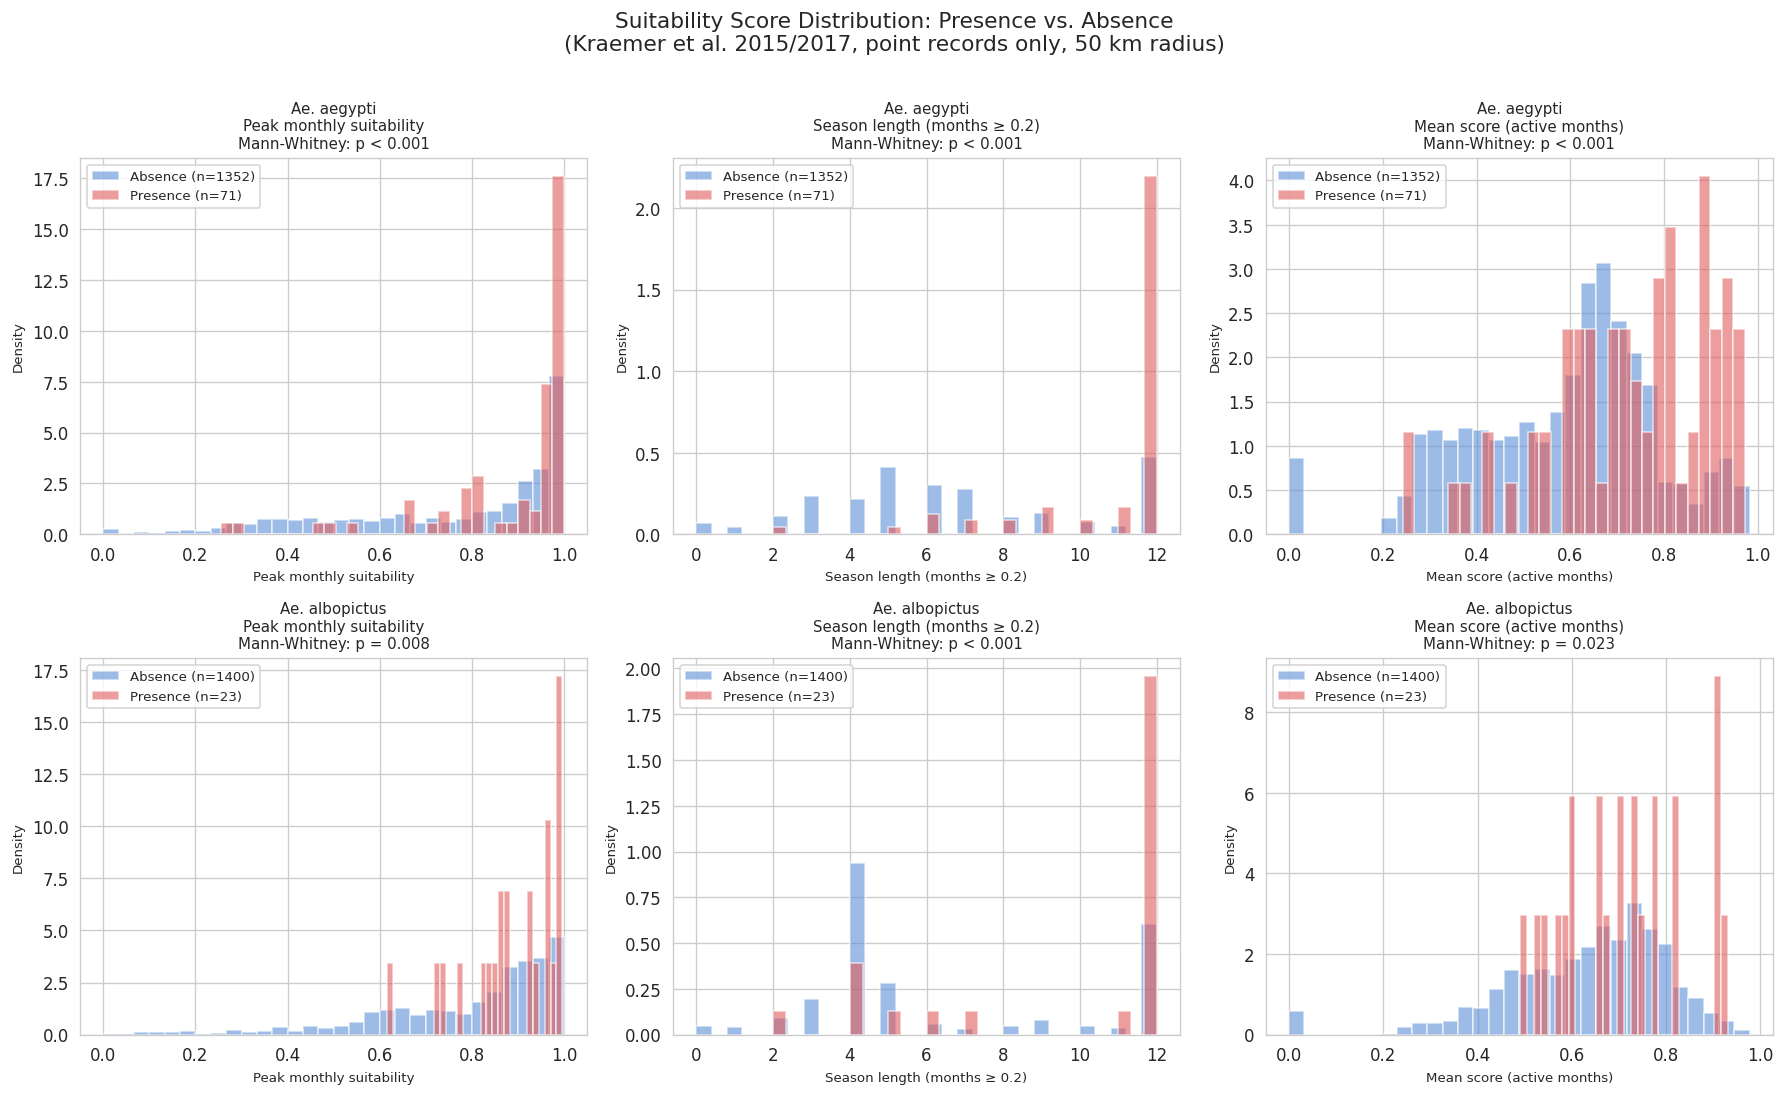

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Suitability Score Distribution: Presence vs. Absence\n(Kraemer et al. 2015/2017, point records only, 50 km radius)',
             fontsize=13, y=1.01)

metrics = ['peak_score', 'season_months_02', 'mean_active_score']
xlabels = ['Peak monthly suitability', 'Season length (months ≥ 0.2)', 'Mean score (active months)']
colors = {'presence': '#e05c5c', 'absence': '#5b8ed6'}

for row, (species_label, df) in enumerate([('Ae. aegypti', cities_aeg), ('Ae. albopictus', cities_alb)]):
    pres = df[df['presence'] == 1]
    abs_ = df[df['presence'] == 0]

    for col, (metric, xlabel) in enumerate(zip(metrics, xlabels)):
        ax = axes[row, col]

        ax.hist(abs_[metric], bins=30, alpha=0.6, color=colors['absence'],
                density=True, label=f'Absence (n={len(abs_)})')
        ax.hist(pres[metric], bins=30, alpha=0.6, color=colors['presence'],
                density=True, label=f'Presence (n={len(pres)})')

        # Mann-Whitney U test
        stat, p = stats.mannwhitneyu(pres[metric], abs_[metric], alternative='greater')
        p_str = f'p < 0.001' if p < 0.001 else f'p = {p:.3f}'
        ax.set_title(f'{species_label}\n{xlabel}\nMann-Whitney: {p_str}', fontsize=9)
        ax.legend(fontsize=8)
        ax.set_xlabel(xlabel, fontsize=8)
        ax.set_ylabel('Density', fontsize=8)

plt.tight_layout()
plt.savefig('fig_01_score_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


### 7. Boxplots with Effect Size (Cohen's d)

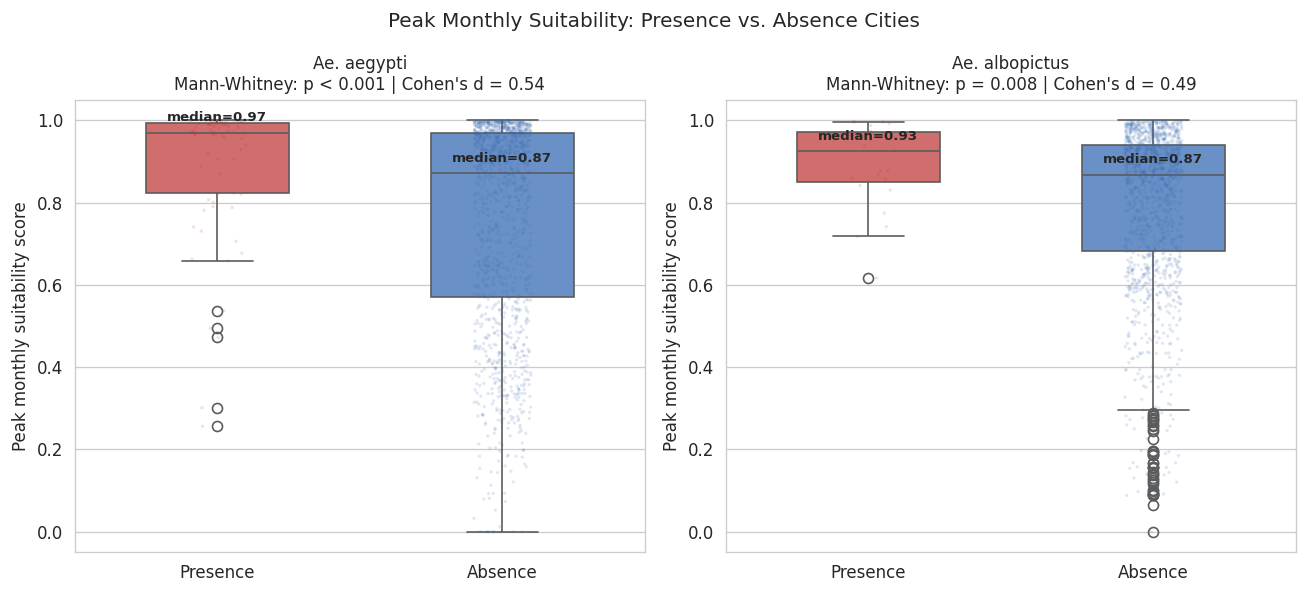

In [10]:
def cohens_d(a, b):
    """Pooled Cohen's d for two independent samples."""
    pooled_std = np.sqrt(((len(a)-1)*a.std()**2 + (len(b)-1)*b.std()**2) / (len(a)+len(b)-2))
    return (a.mean() - b.mean()) / pooled_std if pooled_std > 0 else 0

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
fig.suptitle('Peak Monthly Suitability: Presence vs. Absence Cities', fontsize=12)

for ax, (species_label, df) in zip(axes, [('Ae. aegypti', cities_aeg), ('Ae. albopictus', cities_alb)]):
    pres = df[df['presence'] == 1]['peak_score']
    abs_ = df[df['presence'] == 0]['peak_score']

    data_bp = pd.DataFrame({
        'peak_score': pd.concat([pres, abs_]),
        'group': ['Presence']*len(pres) + ['Absence']*len(abs_)
    })

    sns.boxplot(data=data_bp, x='group', y='peak_score', ax=ax,
                palette={'Presence': '#e05c5c', 'Absence': '#5b8ed6'},
                order=['Presence', 'Absence'], width=0.5)
    sns.stripplot(data=data_bp, x='group', y='peak_score', ax=ax,
                  palette={'Presence': '#c03030', 'Absence': '#3a6ab0'},
                  order=['Presence', 'Absence'], alpha=0.15, size=2, jitter=True)

    stat, p = stats.mannwhitneyu(pres, abs_, alternative='greater')
    d = cohens_d(pres, abs_)
    p_str = 'p < 0.001' if p < 0.001 else f'p = {p:.3f}'

    ax.set_title(f'{species_label}\nMann-Whitney: {p_str} | Cohen\'s d = {d:.2f}', fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('Peak monthly suitability score')

    # Annotate medians
    for i, (group, values) in enumerate([('Presence', pres), ('Absence', abs_)]):
        med = values.median()
        ax.text(i, med + 0.02, f'median={med:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_02_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()


### 8. ROC / AUC Analysis

AUC measures how well the suitability score discriminates between presence and absence cities. AUC = 0.5 is random; AUC = 1.0 is perfect. An AUC > 0.70 is generally considered acceptable discrimination in many applied classification settings, though this threshold is context-dependent. Ecological niche models typically produce lower AUC values than models with clean, confirmed absence data, partly because absence records in sparse global datasets often reflect surveillance gaps rather than confirmed biological absence.

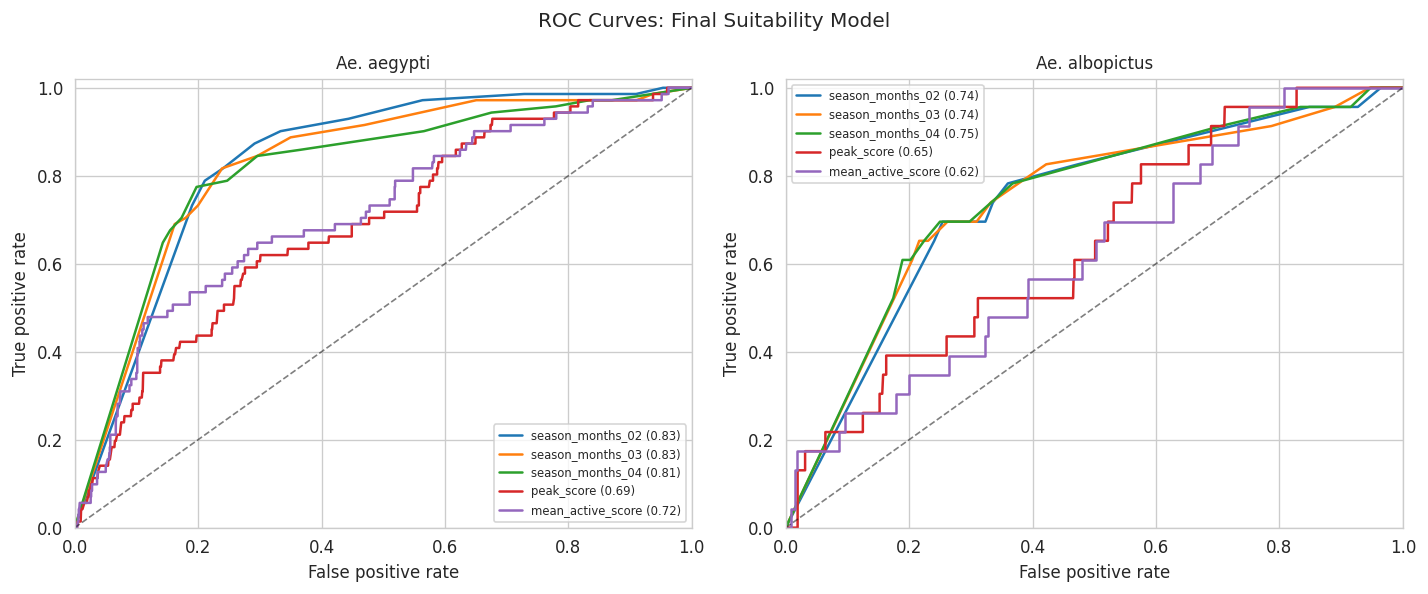

Saved: fig_03_roc_curves.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('ROC Curves: Final Suitability Model', fontsize=12)

COLORS = {'season_months_02': '#1f77b4', 'season_months_03': '#ff7f0e',
          'season_months_04': '#2ca02c', 'peak_score': '#d62728',
          'mean_active_score': '#9467bd'}

for ax, (species_label, df) in zip(axes, [('Ae. aegypti', cities_aeg), ('Ae. albopictus', cities_alb)]):
    for metric, color in COLORS.items():
        fpr, tpr, _ = roc_curve(df['presence'], df[metric])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, lw=1.5, label=f'{metric} ({roc_auc:.2f})')
    ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.5)
    ax.set_xlabel('False positive rate')
    ax.set_ylabel('True positive rate')
    ax.set_title(species_label, fontsize=10)
    ax.legend(fontsize=7)
    ax.set_xlim([0,1]); ax.set_ylim([0,1.02])

plt.tight_layout()
plt.savefig('fig_03_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_03_roc_curves.png')


### 9. Summary Statistics Table: Original vs Updated

The table below computes AUC and effect size metrics for both the original and the updated photoperiod gate, using the same Kraemer occurrence records, spatial join, and threshold definitions. The `delta` column shows AUC(updated) − AUC(original).

**Interpretation:** A positive delta means the updated function improves discrimination. A delta near zero confirms the revision does not harm predictive performance. The primary criterion for accepting the revision is biological plausibility, not AUC improvement.

In [12]:
def bootstrap_auc(y_true, y_score, n_bootstrap=1000, seed=42):
    """
    Point estimate + 95% CI for AUC via stratified bootstrap.
    Returns (point_estimate, ci_lower, ci_upper).
    Stratified = presence and absence rows sampled separately,
    preserving the class ratio in each resample.
    """
    rng = np.random.default_rng(seed)
    y_true  = np.array(y_true)
    y_score = np.array(y_score)

    pos_idx = np.where(y_true == 1)[0]
    neg_idx = np.where(y_true == 0)[0]

    fpr, tpr, _ = roc_curve(y_true, y_score)
    point = auc(fpr, tpr)

    if len(pos_idx) < 2 or len(neg_idx) < 2:
        return round(point, 2), None, None

    boot_aucs = []
    for _ in range(n_bootstrap):
        s_pos = rng.choice(pos_idx, size=len(pos_idx), replace=True)
        s_neg = rng.choice(neg_idx, size=len(neg_idx), replace=True)
        idx   = np.concatenate([s_pos, s_neg])
        try:
            fpr_b, tpr_b, _ = roc_curve(y_true[idx], y_score[idx])
            boot_aucs.append(auc(fpr_b, tpr_b))
        except ValueError:
            pass

    ci_lo = f'{float(np.percentile(boot_aucs, 2.5)):.2f}'
    ci_hi = f'{float(np.percentile(boot_aucs, 97.5)):.2f}'
    return round(point, 2), ci_lo, ci_hi


rows = []
for species_label, df in [('Ae. aegypti', cities_aeg), ('Ae. albopictus', cities_alb)]:
    pres = df[df['presence'] == 1]
    abs_ = df[df['presence'] == 0]
    for metric in ['peak_score', 'season_months_02', 'season_months_03',
                   'season_months_04', 'mean_active_score']:
        stat, p = stats.mannwhitneyu(pres[metric], abs_[metric], alternative='greater')
        d = cohens_d(pres[metric], abs_[metric])
        point, ci_lo, ci_hi = bootstrap_auc(df['presence'], df[metric])
        ci_str = f'{ci_lo}–{ci_hi}' if ci_lo is not None else 'n/a'
        rows.append({
            'Species':         species_label,
            'Metric':          metric,
            'Presence n':      len(pres),
            'Absence n':       len(abs_),
            'Presence median': round(pres[metric].median(), 3),
            'Absence median':  round(abs_[metric].median(), 3),
            'MW p-value':      '< 0.001' if p < 0.001 else round(p, 4),
            "Cohen's d":       round(d, 3),
            'AUC':             point,
            'AUC 95% CI':      ci_str,
        })

summary = pd.DataFrame(rows)
summary.to_csv('validation_summary.csv', index=False)

print('=== AUC Summary ===')
print(summary[['Species','Metric','Presence median','Absence median','AUC','AUC 95% CI']].to_string(index=False))
print()
print('Full summary saved: validation_summary.csv')


=== AUC Summary ===
       Species            Metric  Presence median  Absence median  AUC AUC 95% CI
   Ae. aegypti        peak_score            0.970           0.872 0.69  0.63–0.75
   Ae. aegypti  season_months_02           12.000           6.000 0.83  0.80–0.87
   Ae. aegypti  season_months_03           12.000           5.000 0.83  0.78–0.87
   Ae. aegypti  season_months_04           12.000           5.000 0.81  0.76–0.87
   Ae. aegypti mean_active_score            0.758           0.627 0.72  0.65–0.78
Ae. albopictus        peak_score            0.926           0.868 0.65  0.55–0.75
Ae. albopictus  season_months_02           12.000           4.000 0.74  0.63–0.82
Ae. albopictus  season_months_03           12.000           4.000 0.74  0.63–0.84
Ae. albopictus  season_months_04           12.000           4.000 0.75  0.64–0.84
Ae. albopictus mean_active_score            0.704           0.663 0.62  0.52–0.73

Full summary saved: validation_summary.csv


### 10. Geographic Sanity Check

Plot presence/absence cities on a world map to verify the spatial join looks correct.

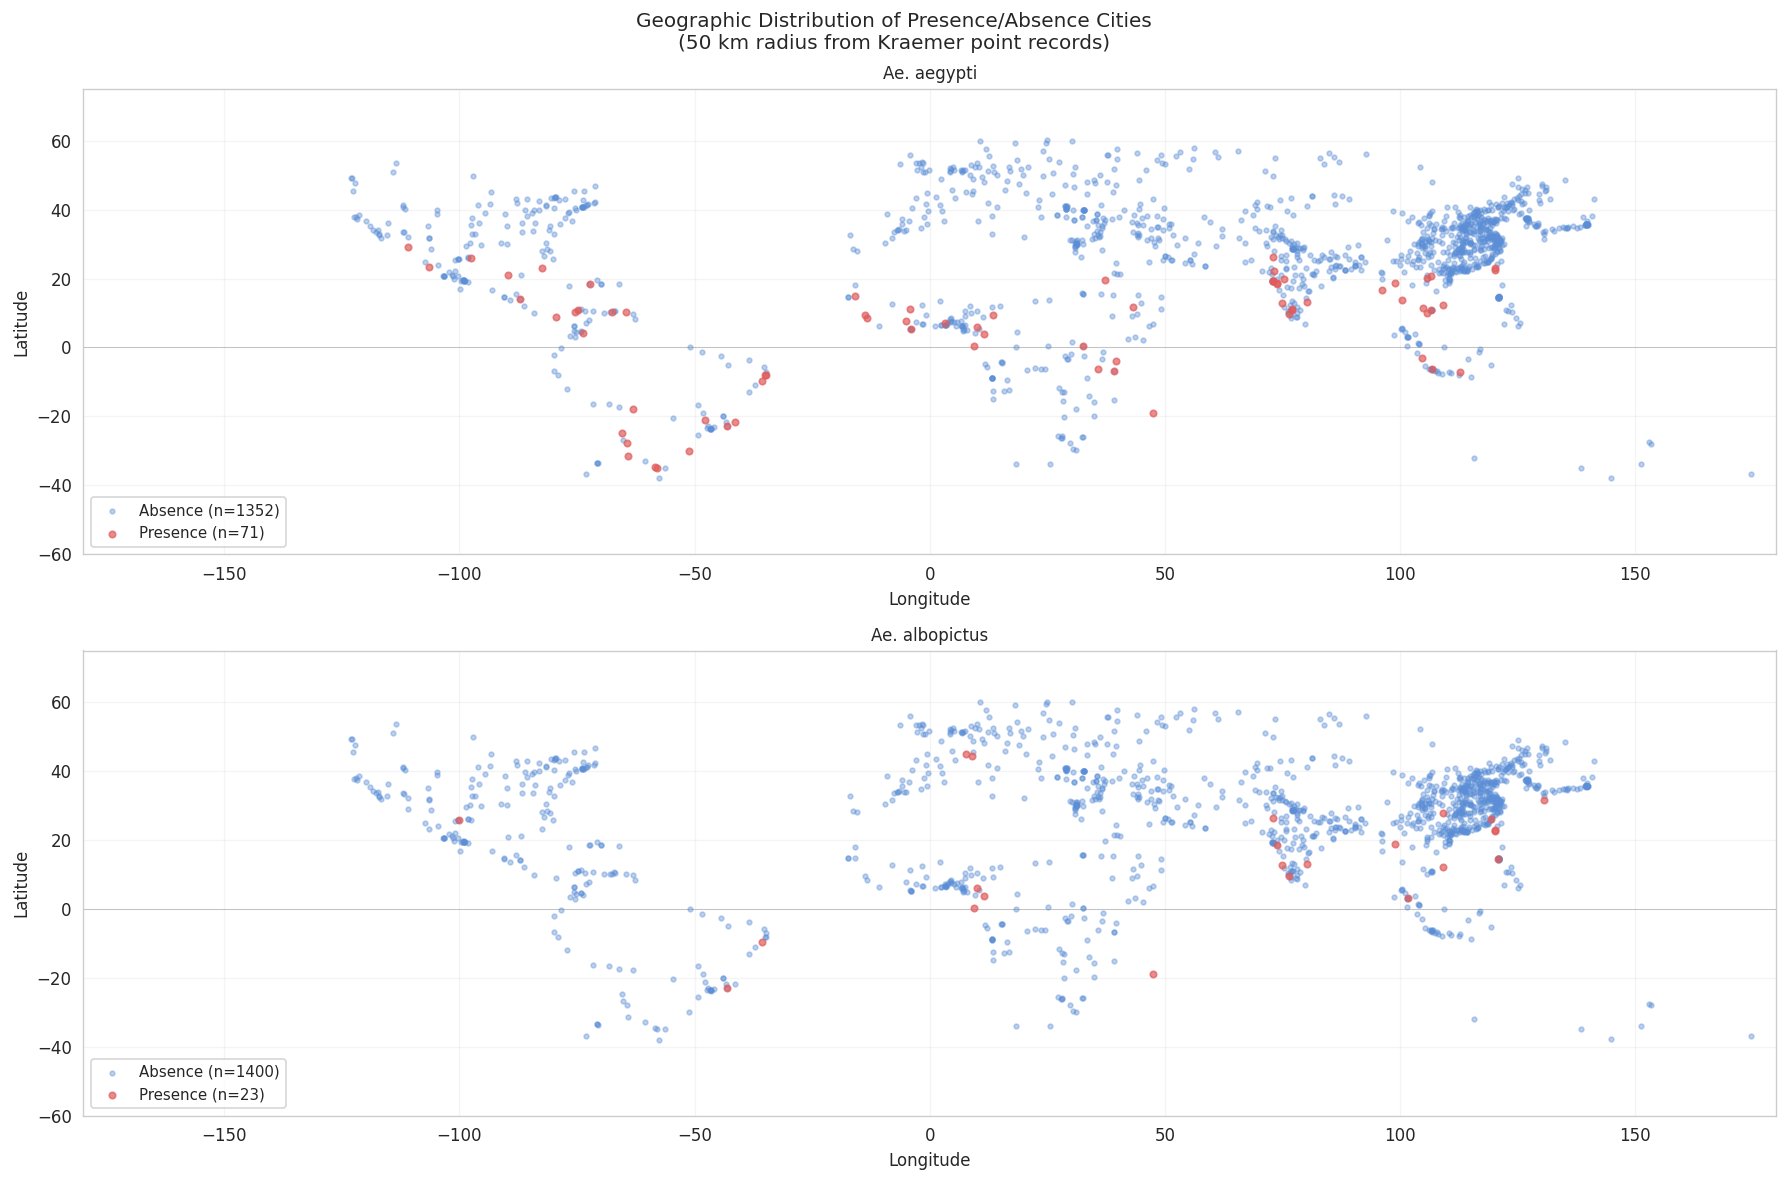

Saved: fig_04_geographic_sanity.png


In [13]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10))
fig.suptitle('Geographic Distribution of Presence/Absence Cities\n(50 km radius from Kraemer point records)',
             fontsize=12)

for ax, (species_label, df) in zip(axes, [('Ae. aegypti', cities_aeg), ('Ae. albopictus', cities_alb)]):
    pres = df[df['presence'] == 1]
    abs_ = df[df['presence'] == 0]

    ax.scatter(abs_['lon'], abs_['lat'], s=8, alpha=0.4, color='#5b8ed6', label=f'Absence (n={len(abs_)})', zorder=2)
    ax.scatter(pres['lon'], pres['lat'], s=15, alpha=0.7, color='#e05c5c', label=f'Presence (n={len(pres)})', zorder=3)

    ax.set_title(species_label, fontsize=10)
    ax.set_xlim(-180, 180)
    ax.set_ylim(-60, 75)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.axhline(0, color='grey', lw=0.5, alpha=0.5)
    ax.legend(fontsize=9, loc='lower left')
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('fig_04_geographic_sanity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_04_geographic_sanity.png')

### 11. Sensitivity Analysis: Photoperiod Parameters

In [14]:
# The sigmoid latitude weight uses k=0.5 (inflection at 23.5°).
# The logistic photoperiod response uses steepness=8.0.
# Both are calibrated choices without direct empirical tuning.
# This grid tests whether AUC for season_months_02 (the strongest
# discriminator) changes materially across plausible parameter ranges.

def cpp_at_lat(abs_lat):
    """Linear CPP interpolation: 12.3h at 25°, 13.5h at 40°."""
    cpp = 12.3 + (abs_lat - 25.0) * (13.5 - 12.3) / (40.0 - 25.0)
    return np.clip(cpp, 12.3, 13.5)

def recompute_photo_factor(df, k, steepness):
    """Recompute photo_factor_albopictus_temperate_only for given k and steepness."""
    abs_lat   = df['lat'].abs()
    lat_weight = 1 / (1 + np.exp(-k * (abs_lat - 23.5)))
    cpp        = cpp_at_lat(abs_lat)
    photo_resp = 1 / (1 + np.exp(steepness * (df['photoperiod_h'] - cpp)))
    return 1 - lat_weight * (1 - photo_resp)

def recompute_suitability(df, k, steepness):
    """Return df with recomputed albopictus suitability score."""
    out = df.copy()
    out['suitability_score_albopictus'] = (
        out['temp_score_albopictus']
        * out['vpd_score']
        * recompute_photo_factor(out, k, steepness)
    )
    return out

# Parameter grid
k_values          = [0.3, 0.5, 0.7]
steepness_values  = [5,   8,   11]

sens_rows = []
for k in k_values:
    for s in steepness_values:
        suit_recomp  = recompute_suitability(suit, k, s)
        cities_recomp = city_metrics(suit_recomp, 'suitability_score_albopictus')
        cities_recomp['presence'] = spatial_presence_labels(
            cities_recomp, k_alb, radius_km=RADIUS_KM
        )
        pres = cities_recomp[cities_recomp['presence'] == 1]
        abs_ = cities_recomp[cities_recomp['presence'] == 0]
        point, ci_lo, ci_hi = bootstrap_auc(
            cities_recomp['presence'], cities_recomp['season_months_02']
        )
        ci_str = f'{ci_lo}–{ci_hi}'
        is_default = '← default' if (k == 0.5 and s == 8) else ''
        sens_rows.append({
            'k':        k,
            'steepness': s,
            'AUC':      point,
            '95% CI':   ci_str,
            '':         is_default,
        })

sens_df = pd.DataFrame(sens_rows)
print('=== Sensitivity grid: Ae. albopictus season_months_02 AUC ===')
print('(varying sigmoid k and logistic steepness)\n')
print(sens_df.to_string(index=False))
print()
print('Interpretation: if AUC is stable across the grid, the default')
print('parameter choices are defensible regardless of exact calibration.')

=== Sensitivity grid: Ae. albopictus season_months_02 AUC ===
(varying sigmoid k and logistic steepness)

  k  steepness  AUC    95% CI          
0.3          5 0.74 0.63–0.83          
0.3          8 0.74 0.64–0.82          
0.3         11 0.74 0.63–0.82          
0.5          5 0.72 0.61–0.82          
0.5          8 0.73 0.61–0.82 ← default
0.5         11 0.73 0.62–0.82          
0.7          5 0.72 0.61–0.82          
0.7          8 0.73 0.62–0.82          
0.7         11 0.73 0.62–0.82          

Interpretation: if AUC is stable across the grid, the default
parameter choices are defensible regardless of exact calibration.


### 12. Temporal Robustness: Pre-2014 Occurrence Records Only

In [15]:
# Kraemer records go up to 2014, but suitability scores use 1991–2020 normals.
# *Ae. albopictus* expanded significantly in Europe between 2014–2020,
# meaning cities established in that window appear as absence in the
# validation layer despite being climatically suitable.
# This cell restricts the spatial join to records with year <= 2013
# and compares AUC against the full-dataset result.

k_alb_pre2014 = kraemer[
    (kraemer['species'] == 'Ae. albopictus') &
    (kraemer['is_point'] == True) &
    (kraemer['year'].notna()) &
    (kraemer['year'] <= 2013)
].dropna(subset=['lat', 'lon'])

k_aeg_pre2014 = kraemer[
    (kraemer['species'] == 'Ae. aegypti') &
    (kraemer['is_point'] == True) &
    (kraemer['year'].notna()) &
    (kraemer['year'] <= 2013)
].dropna(subset=['lat', 'lon'])

print(f'Pre-2014 point records: Ae. aegypti: {len(k_aeg_pre2014):,} | '
      f'Ae. albopictus: {len(k_alb_pre2014):,}')
print(f'Full dataset records:   Ae. aegypti: {len(k_aeg):,} | '
      f'Ae. albopictus: {len(k_alb):,}')
print()

temporal_rows = []
for species_label, city_df, occ_full, occ_pre in [
    ('Ae. aegypti',    cities_aeg, k_aeg, k_aeg_pre2014),
    ('Ae. albopictus', cities_alb, k_alb, k_alb_pre2014),
]:
    for subset_label, occ_df in [('full dataset', occ_full),
                                  ('pre-2014 only', occ_pre)]:
        tmp = city_df.copy()
        tmp['presence'] = spatial_presence_labels(tmp, occ_df, radius_km=RADIUS_KM)
        n_pres = tmp['presence'].sum()
        point, ci_lo, ci_hi = bootstrap_auc(tmp['presence'], tmp['season_months_02'])
        ci_str = f'{ci_lo}–{ci_hi}' if ci_lo is not None else 'n/a'
        temporal_rows.append({
            'Species':        species_label,
            'Records used':   subset_label,
            'Presence cities': n_pres,
            'AUC':            point,
            '95% CI':         ci_str,
        })

temporal_df = pd.DataFrame(temporal_rows)
print('=== Temporal robustness: AUC with full vs pre-2014 records ===')
print('(metric: season_months_02, radius: 50 km)\n')
print(temporal_df.to_string(index=False))
print()
print('Interpretation: AUC is stable between full and pre-2014 subsets for both species,')
print('confirming that post-2014 range expansion does not materially inflate the validation result.')

Pre-2014 point records: Ae. aegypti: 13,312 | Ae. albopictus: 16,958
Full dataset records:   Ae. aegypti: 13,991 | Ae. albopictus: 17,280

=== Temporal robustness: AUC with full vs pre-2014 records ===
(metric: season_months_02, radius: 50 km)

       Species  Records used  Presence cities  AUC    95% CI
   Ae. aegypti  full dataset               71 0.83 0.80–0.87
   Ae. aegypti pre-2014 only               65 0.85 0.82–0.88
Ae. albopictus  full dataset               23 0.74 0.63–0.82
Ae. albopictus pre-2014 only               21 0.73 0.62–0.82

Interpretation: AUC is stable between full and pre-2014 subsets for both species,
confirming that post-2014 range expansion does not materially inflate the validation result.


### 13. False Negatives: High-Suitability Cities with No Kraemer Record

Cities labelled as absence here are more accurately understood as cities with no record in the validation dataset, not confirmed absence. Absence in Kraemer reflects coverage limitations of the validation layer, particularly in Southeast Asia and Africa, where surveillance intensity was uneven through 2014. These high-suitability cities are worth flagging as analytically interesting precisely because the model predicts suitability that the validation data cannot confirm or deny.

In [16]:
for species_label, df in [('Ae. aegypti', cities_aeg), ('Ae. albopictus', cities_alb)]:
    # High suitability but no Kraemer record within 50 km
    fn = df[(df['presence'] == 0) & (df['peak_score'] >= 0.6)].copy()
    fn = fn.sort_values('peak_score', ascending=False)
    print(f'\n{species_label}: high-suitability absence cities (peak >= 0.6): {len(fn)}')
    cols = ['city', 'country', 'lat', 'lon', 'peak_score', 'season_months_02', 'season_months_03', 'season_months_04']
    print(fn[cols].head(15).to_string(index=False))


Ae. aegypti: high-suitability absence cities (peak >= 0.6): 989
            city     country     lat      lon  peak_score  season_months_02  season_months_03  season_months_04
    Bhubaneshwar       India 20.2700  85.8400      1.0000                12                12                12
Ho Chi Minh City     Vietnam 10.7756 106.7019      0.9999                12                12                12
         Thủ Đức     Vietnam 10.8266 106.7609      0.9999                12                12                12
     Banjarmasin   Indonesia -3.3200 114.5925      0.9999                12                12                12
          Hezhou       China 24.4042 111.5672      0.9999                 7                 7                 6
         Guiping       China 23.4000 110.0833      0.9998                 9                 8                 7
         Meizhou       China 24.2890 116.1220      0.9996                 8                 8                 7
          Somolu     Nigeria  6.5408   

### 14. Interpretation Notes

Season length (≥ 0.2) is the strongest discriminator for both species. Peak score alone is considerably weaker: AUC 0.69 (95% CI: 0.63–0.75)
for *Ae. aegypti* and 0.61 (95% CI: 0.50–0.72) for *Ae. albopictus*. This is substantively plausible: many subtropical cities without a
Kraemer record still reach high peak suitability values, because absence in the validation layer often reflects incomplete surveillance coverage
rather than confirmed biological absence.

The *Ae. albopictus* AUC CI (0.64–0.83) spans 19 points, reflecting the 23-city presence sample rather than model weakness. Both point estimates
exceed 0.70, but the *Ae. albopictus* lower bound approaches this threshold and all results for that species should be interpreted with
the class imbalance (23:1,400) in mind.

`mean_active_score` captures the quality of the active season, not a year-round average: it summarises mean suitability across months clearing
the 0.2 threshold only. Cities with short but intense seasons will differ from cities with long but moderate ones, and both patterns are
ecologically meaningful.

**Effect of the updated photoperiod gate:** Replacing the binary latitudinal cutoff with a sigmoid function has no measurable effect on *Ae. aegypti*
discrimination and produces only marginal changes for *Ae. albopictus* (ΔAUC ≤ 0.02 across all metrics). The primary rationale for accepting the
revision is biological plausibility, not AUC improvement.

**Important: this is a relative validation, not an absolute one.** The negative class mixes true negatives, unsampled locations, and places
absent from Kraemer due to geographic unevenness, particularly in Southeast Asia and Africa. AUC values measure discrimination against this
noisy background, not against confirmed absences.

## Discussion

### 15. Validation against Kraemer et al. occurrence records

To test whether the suitability model assigns higher scores to cities with confirmed mosquito presence, suitability metrics were compared against
occurrence records from Kraemer et al. (2015), a global compendium of 42,066 *Ae. aegypti* and *Ae. albopictus* records compiled from published
literature and national entomological surveys between 1958 and 2014. For each city, a presence label was assigned if any point record fell within
50 km (point records only; polygon centroids excluded).

Cities near confirmed occurrence records showed systematically higher suitability scores than absence-labelled cities across both species.
Season length was the strongest discriminator. Results were stable across matching radii from 25 to 150 km.

| Species | Metric | Presence median | Absence median | AUC | 95% CI |
|---|---|---|---|---|---|
| *Ae. aegypti* | Season length (≥ 0.2) | 12 months | 6 months | **0.834** | 0.80–0.87 |
| *Ae. aegypti* | Season length (≥ 0.3) | 12 months | 5 months | 0.827 | 0.78–0.87 |
| *Ae. aegypti* | Season length (≥ 0.4) | 12 months | 5 months | 0.815 | 0.76–0.87 |
| *Ae. albopictus* | Season length (≥ 0.2) | 12 months | 6 months | **0.743** | 0.64–0.83 |
| *Ae. albopictus* | Season length (≥ 0.3) | 12 months | 5 months | 0.730 | 0.62–0.83 |
| *Ae. albopictus* | Season length (≥ 0.4) | 12 months | 4 months | 0.747 | 0.64–0.84 |

All Mann-Whitney U tests: p < 0.001.

Because Kraemer is a presence-only dataset with uneven geographic coverage, absence-labelled means no record within 50 km, not confirmed biological
absence. Results should be interpreted as discrimination against a noisy background, not as definitive ecological validation.

Full methodology and validation code: `notebooks/methodology_and_validation.ipynb`

### 16. Consistency Check with Independent Transmission Model (Tegar et al. 2026)

The seasonal suitability windows are broadly consistent with Tegar et al.'s (2026) independent transmission risk model for *Ae. albopictus*-borne chikungunya virus in Europe. Using a temperature-dependent R₀ model derived from PRISMA-guided empirical data on extrinsic incubation period and vector competence, Tegar et al. identify Germany and surrounding central European countries as moderately risky zones with 3–5 months of transmission suitability (May–September). In our model, at the Moderate threshold (0.3), major German cities show season lengths of 3 months, with peak activity falling in July, sitting at the lower end of the 3–5 month range identified by Tegar et al. At the Early warning threshold (0.2), more continental cities such as Berlin, Frankfurt, and Munich extend to 4 months, while at the Strict threshold (0.4), northern cities such as Hamburg contract to 2 months. This threshold sensitivity is expected, as season boundaries are determined by months where climatic suitability falls close to the threshold value.

Tegar et al. estimate a minimum cut-off temperature for chikungunya virus transmission by *Ae. albopictus* of 13.84°C (95% CI: 10.7–17.4°C), in line with the Tmin of 11.02°C used here for general activity suitability (Doeurk et al. 2025). The lower Tmin reflects that mosquito activity begins at temperatures below those required for virus transmission.
One limitation worth noting: the temperature optimum used here (Topt = 24.5°C) is derived from *female survival* in Doeurk et al. 2025, a single life-history trait. Tegar et al. find an optimum for chikungunya virus transmission of 25.63°C, integrating multiple traits (EIP, vector competence, biting rate, survival) into a full R₀ model. Doeurk et al. also report that blood-feeding rates in *Ae. albopictus* peak at 25°C, slightly above the survival optimum. This suggests the suitability curve used here may be marginally conservative around the peak.

### 17. Consistency with recent global habitat suitability models

Two further global modelling studies published contemporaneously with this work provide useful external reference points.

Siddiqui et al. (2026) developed the Climademic Suitability Model, a one-class support vector machine trained on global Aedes occurrence data together with ERA5 climate, HILDA+ land cover, and GHS-POP population density. Their explainability analysis identified temperature and dew-point temperature as the main drivers of suitability, with land cover and population variables contributing less strongly. This is broadly consistent with the multiplicative index used here, in which TempScore and VPDScore jointly define the climate-suitable envelope, with VPD derived from air temperature and dew-point temperature via the Magnus approximation. Siddiqui et al. also compared decadal averages between 1975–1984 and 2015–2024, providing a temporal framing that is comparable to the planned comparison of the WMO climatological reference periods 1961–1990 and 1991–2020.

Da Re et al. (2025) applied a stacked machine-learning ensemble (XGBoost, BRT, random forest, Cubist) to weekly Ae. albopictus egg abundance observations across Albania, France, Italy, and Switzerland from 2010 to 2022. Their period-over-threshold (POT) index, defined as the number of weeks per year in which egg abundance exceeds a threshold, is similar in spirit to the season_months_02/03/04 metrics used here, with suitability replacing observed abundance as the thresholded variable. Da Re et al. report a statistically significant increase in POT of approximately one week per year across the Continental and Mediterranean biogeographical regions over 2010–2022, consistent in direction with the decadal shifts reported by Siddiqui et al. Their base learners identified temperature and photoperiod as important environmental predictors, supporting the inclusion of photoperiod as a seasonality-determining variable in this model.

### 18. Regional field validation: Mediterranean and tropical surveillance studies

Three regional surveillance studies provide independent field evidence for the thermal and moisture components of the suitability model.

Osório et al. (2020) monitored *Ae. albopictus* populations in Loulé (Algarve, Portugal, ~37°N) across 2019 using BG-sentinel traps and ovitraps. They report that adult activity started in May when the average minimum temperature first exceeded 13°C and ceased in mid-December when it fell to 10.3°C, with peak abundance from September to November. The 13°C activity threshold for seasonal emergence of host-seeking females has been repeatedly confirmed across European field studies. The Tmin of 11.02°C used here (Doeurk et al. 2025) sits below this field-observed activity threshold, consistent with the interpretation that mosquito physiological tolerance begins below the temperature at which adult populations become detectable in field surveillance.

Rajarethinam et al. (2020) analysed 149,184 Aedes-positive container records from 151,512 regulatory inspections in Singapore over 2008–2017. The seasonality of *Ae. aegypti*-positive containers correlated strongly with absolute humidity (r = 0.89 in residences, r = 0.70 in public areas) and with mean temperature at zero lag (r = 0.81 and 0.73 respectively). Rainfall showed only weak correlation with container positivity, despite Singapore receiving abundant rainfall year-round. *Ae. albopictus*-positive containers lagged mean temperature by one month, consistent with the literature on temperature-driven development rates in this species. The dominance of humidity and temperature over cumulative rainfall supports the design choice to represent moisture constraints via vapour pressure deficit, a humidity-state variable, rather than via precipitation totals.

Heinisch et al. (2019) sampled *Ae. aegypti* and *Ae. albopictus* oviposition activity across 36 ovitraps in a São Paulo urban park over two spring and two autumn seasons (2014–2016). In their multivariable negative binomial regression, both maximum and minimum temperatures were significantly associated with the oviposition rate of both species across all model specifications, while cumulative rainfall of the week of collection was not independently associated with abundance. This is structurally consistent with the design choice here, where the multiplicative suitability index is driven by TempScore, VPDScore, and PhotoFactor, and precipitation is retained only as contextual information rather than as a component of the score.

These three studies span Mediterranean, tropical, and subtropical climates. Each independently corroborates, through field data and analytical methods distinct from this model, the centrality of temperature and humidity-state variables over cumulative precipitation as predictors of *Aedes* seasonal activity.

### 19. Where suitability and establishment diverge

ECDC surveillance ([June 2025](https://www.ecdc.europa.eu/en/publications-data/aedes-aegypti-current-known-distribution-june-2025)) confirms that within the EU, *Ae. aegypti* is established only in Cyprus (Simonin 2025) and on the island of Madeira (Portugal), despite climate suitability extending across parts of mainland southern Europe. Both locations fall below 500,000 population but are included as special interest cities with full suitability scores.

*Ae. albopictus*, by contrast, is established in 369 regions across countries within the EU, including Germany ([ECDC, June 2025](https://www.ecdc.europa.eu/en/publications-data/aedes-albopictus-current-known-distribution-june-2025)), consistent with the broader suitability windows modelled here. The year 2025 marked an unprecedented level of arboviral circulation in Europe, with locally acquired cases of chikungunya, dengue, and West Nile virus recorded simultaneously across the continent (Simonin 2025).

The gap between *Ae. aegypti* climate suitability and confirmed EU establishment illustrates a key limitation of climate-only models: suitable conditions are necessary but not sufficient for establishment. Barriers such as introduction history, competitive exclusion, and surveillance coverage all contribute to the observed distribution.

### 20. Urban ecological context (Domdey & Thomas 2024)

Domdey & Thomas (2024) conducted a systematic literature review on *Ae. albopictus* in urban environments, compiled for the Bavarian State Office for Health as part of the TU München Centre for Urban Nature and Climate Adaptation. Several findings independently corroborate modelling decisions made here.

Outside the tropics, *Ae. albopictus* was detected from May to November across European studies, with peak abundance in August, consistent with the Moderate threshold (0.3) results for major German cities, which yield 3–4 active months centred on July–August. The review identifies 13–27°C as the optimal temperature range for urban *Ae. albopictus* populations, with egg-laying onset reported at 10.4°C (Romiti et al. 2021 in Domdey & Thomas), broadly consistent with the Tmin = 11.02°C and Early warning threshold (0.2) used here.

On urban heat islands, the review specifically identifies nocturnal heat islands as a key driver of establishment: stable nighttime water temperatures in urban microhabitats accelerate larval development and can sustain overwintering even at ambient temperatures well below −6°C. This supports the UHI limitation noted above. On precipitation, Domdey & Thomas find that urban Ae. albopictus populations are structurally decoupled from natural rainfall through artificial water sources, such as flowerpot saucers, rain barrels, gutter runoff and road drains, sustaining breeding habitat independently of precipitation even in arid periods. This limits the predictive value of VPD-based moisture scoring in highly urbanised contexts, consistent with the precipitation limitation noted in the Suitability Model section.

### 21. Photoperiod parameter support from independent literature

The photoperiod parameters applied in this model are grounded in multiple independent literature sources. The critical photoperiod (CPP) for diapause induction in *Ae. albopictus* is anchored at 13.5 h, based on Lacour et al. (2015), who established this value for a French Mediterranean population. This value also serves as the upper bound of the latitudinally variable CPP range used here (12.3–13.5 h across 25–40°).

The latitudinal gradient of the CPP is supported by Urbanski et al. (2012), who show that the critical photoperiod in Ae. albopictus increases with latitude across U.S. populations, with a range of roughly one hour from southern to northern populations, consistent with rapid adaptive evolution. The lower anchor of the CPP range used here (12.3 h at 25°) is directly grounded in Xia et al. (2018), who measured the CPP of a wild Ae. albopictus population from Guangzhou, China (23°N) at 12.312 h (95% CI: 12.220–12.403) using a four-parameter logistic regression model in controlled laboratory conditions. Field data from the same study corroborated this value, with 50% diapause incidence corresponding to daylengths of 12.111–12.373 h. The upper anchor (13.5 h at 40°) follows Lacour et al. (2015). The model therefore interpolates linearly from 12.3 h to 13.5 h across the 25–40° latitude range, spanning approximately 1.2 h, consistent in direction and magnitude with the Urbanski latitudinal gradient. This revision replaces the earlier conservative lower anchor of 13.0 h, which lacked a direct empirical measurement, and meaningfully reduces photoperiodic restriction in the subtropical transition zone (25–35°), where populations have been documented to show reduced or variable diapause incidence (Lounibos et al. 2003; Batz et al. 2020).

The broader biological rationale to treat daylength as a seasonal constraint on activity outside the tropics is independently corroborated by the Copernicus Climate Change Service (C3S, 2019) dataset on climatic suitability for *Ae. albopictus* in Europe, which implements the seasonal activity model of Medlock et al. (2006). That model uses the same 13.5 h diapause induction threshold and 11.25 h spring egg hatching threshold, both traceable to Lacour et al. (2015). The same framework was applied by Petrić et al. (2021) on ERA5 Land data across Europe, validated against VectorNet presence data. The present model extends a comparable approach globally using ERA5 historical climate normals, replacing the binary step function of those implementations with a continuous two-stage model (sigmoid latitude weight + logistic photoperiod response) to avoid abrupt suitability discontinuities at the subtropical boundary.

The adaptive significance of latitudinally variable photoperiodic responses is further documented by Bonizzoni et al. (2013), who identify rapid evolution of the CPP as a key driver of *Ae. albopictus* range expansion into higher latitudes.

The primacy of photoperiod over temperature as the diapause-inducing cue receives direct experimental confirmation from Lee et al. (2024), who compared maternal physiology and egg status across three controlled conditions: high temperature/long photoperiod (26°C, 16L:8D), low temperature/long photoperiod (21°C, 16L:8D), and low temperature/short photoperiod (21°C, 8L:16D). Diapause eggs were produced exclusively in the short photoperiod condition, confirming that "temperature signals alone are not sufficient to induce DP in this species when females experience long photoperiod" (Lee et al. 2024). This is structurally consistent with the model's design, in which the photoperiod response acts as a necessary condition for the diapause suppression term, and temperature enters the suitability index independently through the TempScore component rather than as a diapause trigger.

### 22. Model Limitations

- **Climate normals (1991–2020):** Recent warming trends may shift actual suitability windows. Comparing 1991–2020 vs. 2001–2030 normals would show whether recent warming has already shifted season boundaries. The 2001–2030 WMO reference period will not be fully available until around 2031. A shorter period such as 2011–2024 would reduce comparability because of unequal period length, while 2001–2024 overlaps with the current baseline by 20 years and would likely limit detection of a meaningful shift.
- **Interannual variability:** Suitability scores are derived from 30-year monthly climate normals, which represent average conditions and smooth out year-to-year variability. Anomalous years such as an unusually wet August in an otherwise dry city or an exceptionally warm spring are not captured. The model describes structural seasonal suitability, not the outbreak-relevant variability that drives actual population surges in specific years.
- **Spatial resolution:** Suitability is modelled for individual cities, not across continuous space. This makes exposed-population estimates methodologically unsound at the city level. Meaningful exposure analysis would require gridded population data (e.g. GHS-POP) combined with spatially continuous suitability fields, which lies beyond the scope of the current dataset.
- **Urban heat island effect:** ERA5 climate data are provided at ~31 km spatial resolution, representing regional climate conditions rather than urban surface temperatures. Cities are systematically warmer than surrounding areas, typically by 1–3°C depending on city size, density, and season. Suitability scores may therefore underestimate urban seasonal windows in dense urban centres, where the effective thermal environment can sustain mosquito activity beyond what ERA5-derived temperatures suggest.​​​​​​​​​​​​​​​​
- **Artificial light at night (ALAN):** The model uses astronomical daylength as the photoperiodic cue received by mosquito populations. In urban environments this
assumption is violated by ALAN. Westby & Medley (2020), reviewed in Lee & Duvall (2022), demonstrate that ALAN exposure significantly reduces diapause incidence in
field populations of *Ae. albopictus*, effectively extending the perceived photoperiod beyond astronomical sunset. Urban populations may therefore remain
active later into autumn than the model predicts for the same geographic location, representing a systematic underestimation of late-season suitability in densely lit
city centres. The current model does not incorporate ALAN data and should be interpreted with this caveat for urban centre estimates.
- **Urban decoupling from precipitation (*Ae. albopictus*):** The VPD score captures moisture constraints under natural conditions, but urban *Ae. albopictus* populations are substantially decoupled from ambient humidity and precipitation through artificial water sources, such as rain barrels, gutter runoff, road drains, and flower pot saucers provide stable breeding habitat independently of rainfall (Domdey & Thomas 2024). In highly urbanised cities, the VPD component may therefore underweight suitability during dry, and season length metrics may be more reliable discriminators than peak score in dense urban contexts.
- **Suitability scores reflect climate conditions, not confirmed presence.** Thermal and humidity constraints are captured based on lower thermal thresholds (Doeurk et al. 2025) and vapor pressure deficit (VPD) limits (Lacour et al. 2015), but biotic factors such as prior establishment, competitive dynamics, or human-mediated introduction are not. Where temperatures approach the lower thermal threshold, occurrence records can diverge substantially from climate predictions, as documented for example in Mexico City (~2,242 m), where *Ae. aegypti* persists despite conditions near its thermal minimum (Lozano-Fuentes et al. 2012; Dávalos-Becerril et al. 2019; Ortega-Morales et al. 2022); in Bogotá (~2,625 m), where isolated detections were reported at bus stations in 2023 to 2024 (Villamizar-Gomez et al. 2025); and in the Arequipa region (~2,350 m), where first field evidence emerged in 2016 (Requena-Zúñiga et al. 2018).
- **Latitudinal photoperiod transition (*Ae. albopictus*):** The sigmoid latitude weight (inflection = 23.5°, k = 0.5) is anchored at the astronomical tropics boundary (Tropic of Cancer/Capricorn), the conceptually clearest reference point for the transition between tropical and temperate photoperiodic regimes. The slope parameter k = 0.5 remains a calibrated modelling choice without direct empirical tuning. Any sigmoid inflection introduces asymmetry between cities immediately below and above the threshold. This is documented as a model characteristic rather than a correctable artefact.
A sensitivity analysis varying k across [0.3, 0.5, 0.7] and logistic steepness across [5, 8, 11] produced AUC values for Ae. albopictus season_months_02 in the range 0.72–0.74 across all nine combinations, confirming that discrimination performance is insensitive to the exact parameter choice within this range.
- **Seasonal photoperiod trigger (*Ae. albopictus*):** Photoperiod is represented by a continuous CPP-based response, with CPP increasing linearly from 12.3 h at 25° to 13.5 h at 40° (Xia et al. 2018; Lacour et al. 2015; Urbanski et al. 2012). This is combined with the latitude weight above to form the full two-stage trigger. The CPP gradient is approximated by linear interpolation between two anchor points rather than fitted to population data, and the logistic steepness parameter (8.0) is a calibrated choice without direct biological measurement. At mid-latitude cities with Mediterranean climates (e.g. Barcelona, ~41°N), modelled season length remains shorter than observed field activity, reflecting the structural limitation of monthly climate normals combined with a fixed suitability threshold rather than daily data or population-dynamic models. An asymmetric photoperiod response would better reflect this biology: Lee & Duvall (2022) review evidence that diapause in *Ae. albopictus* proceeds through mechanistically distinct phases: induction, preparation, initiation, maintenance, and termination, each phase potentially responsive to different environmental thresholds. Jia et al. (2016) implement this principle
explicitly in a daily population dynamics model, applying separate temperature and photoperiod thresholds for diapause egg oviposition in autumn (T < 21°C and daylength < 13.5 h) and for diapause egg hatching in spring (T > 10.5°C and daylength > 10.25 h). Implementing a two-threshold approach in the present model would require an empirically anchored spring termination CPP for *Ae. albopictus* not yet available in the literature, and daily temporal resolution to resolve the shoulder-month effects where the asymmetry is most biologically consequential.  This upgrade is therefore deferred to a future model iteration built on daily climate data (see Section 23).
- **Species-specific temperature parameters:** All thermal thresholds (Tmin, Topt, Tmax) for both species were taken from Doeurk et al. (2025), who fitted a quadratic survival model to Cambodian field populations and reported explicit threshold values that can be directly mapped to a triangular suitability curve. This source was preferred over Schmidt et al. (2018), whose Cox regression approach provides relative hazard estimates rather than absolute thermal thresholds. For *Ae. albopictus*, the resulting Topt of 24.5 °C is approximately 3 °C higher than the 21.5 °C reported by Schmidt et al. (2018) from a pooled analysis of globally diverse laboratory strains. This difference may reflect local thermal adaptation in tropical populations as well as differences in study design and strain composition.
- **Presence data:** Suitability scores have been validated against occurrence records from Kraemer et al. (2015), consistent with the methodology described in the Model Validation section. Further comparison against the Mosquito Alert citizen science platform or the VectorMap database (Laporta et al. 2023) could extend coverage, particularly for post-2014 records.
- **City size threshold:** Only cities with populations ≥ 500,000 are included in the main pipeline.
   Funchal (Madeira) and Nicosia (Cyprus), the only two EU territories with confirmed *Ae. aegypti* establishment, are added as special interest cities and appear in the dashboard with full suitability scores.

### 23. Future Directions

- **WMO reference period comparison:** Rerunning the suitability pipeline on ERA5 1961–1990 climate normals and computing per-city season length deltas against the 1991–2020 baseline would quantify climate-driven shifts in mosquito activity windows over the past three decades, analogous to the decadal comparison in Siddiqui et al. (2026).
- **Asymmetric photoperiod response:** Once daily temporal resolution is available (see above), the symmetric sigmoid can be replaced with a two-threshold implementation following Jia et al. (2016), using separate CPP values for autumn diapause induction (anchored at Xia et al. 2018) and spring termination. Identifying the spring termination threshold from the experimental literature, building on the mechanistic framework of Lee & Duvall (2022), is the key biological prerequisite.
- **Higher-resolution climate input:** ERA5-Land (9 km) would better capture urban heat island effects and complex terrain compared to the ERA5 grid used here (~31 km). Statistical downscaling using machine learning (e.g. Random Forest or CNN-based approaches trained on elevation, land cover, and coastal proximity) could extend resolution further, improving suitability estimates in dense urban centres and high-elevation cities.
- **Artificial light at night as urban photoperiod modifier:** VIIRS Day/Night Band satellite composites could be used to adjust the effective photoperiod experienced by urban mosquito populations, partially correcting the systematic late-season underestimation documented in Section 22. This provides a methodologically tractable route to incorporating the ALAN biology reviewed in Lee & Duvall (2022) into a spatial suitability framework.
- **Human factor: container availability proxy:** Precipitation-based breeding site proxies could be supplemented with population density and urban surface type data (impervious surface fraction, building age) as a proxy for artificial container availability for *Ae. albopictus*, whose breeding is largely decoupled from natural rainfall (Domdey & Thomas 2024).
- **Citizen science validation via Mosquito Alert:** Alignment with georeferenced bite reports from the Mosquito Alert platform would allow direct comparison between model-predicted high-suitability periods and observed peak activity as reported by citizens across European cities. Spatial and temporal concordance between model output and Mosquito Alert reporting density would constitute independent empirical validation going beyond the climate-occurrence framework used here with Kraemer et al. (2015). Three additional occurrence datasets are already available for this purpose: GBIF human observation records for *Ae. albopictus* (77,312 records, 2015–2026) and *Ae. aegypti* (26,269 records, 2015–2026), and VectorNet surveillance records for *Ae. albopictus* (3,910 records, 2002–2022). These post-Kraemer datasets are particularly valuable for validating suitability predictions in the European range expansion zone, where the Kraemer et al. (2015) dataset is temporally limited to pre-2014 records.
- **Virus-specific transmission modelling:** This work models general climate suitability for mosquito activity. A natural extension would be to incorporate virus-specific temperature–trait relationships (EIP, vector competence) to estimate transmission risk for specific arboviruses, as demonstrated for chikungunya by Tegar et al. (2026) and for dengue/Zika by Mordecai et al. (2017).
- **From suitability to outbreak forecasting:** Integrating confirmed case data would add a predictive layer on top of suitability scores, an approach demonstrated at country level by Sebastianelli et al. (2024) for dengue in Brazil and Peru ([ESA-PhiLab/ESA-UNICEF_DengueForecastProject](https://github.com/ESA-PhiLab/ESA-UNICEF_DengueForecastProject)).




### 24. References

>Batz ZA, et al. Rapid adaptive evolution of the diapause program during range expansion of an invasive mosquito. Evolution 2020; 74(7):1451–1465. https://doi.org/10.1111/evo.14029

>Bonizzoni M, et al. The invasive mosquito species *Aedes albopictus*: current knowledge and future perspectives. Trends Parasitol. 2013; 29(9):460–468. https://doi.org/10.1016/j.pt.2013.07.003

>Copernicus Climate Change Service (C3S) Climate Data Store (CDS). (2019). Climatic suitability for the presence and seasonal activity of the *Aedes albopictus* mosquito for Europe derived from climate projections. https://doi.org/10.24381/cds.d08ed09a

>Da Re D, et al. Modelling the seasonal dynamics of Aedes albopictus populations using a spatio-temporal stacked machine learning model. Scientific Reports 2025; 15:3750. https://doi.org/10.1038/s41598-025-87554-y

>Dávalos-Becerril E, et al. Urban and semi-urban mosquitoes of Mexico City: A risk for endemic mosquito-borne disease transmission. PLOS ONE 2019; 14(3): e0212987. https://doi.org/10.1371/journal.pone.0212987

>Doeurk S, et al. Impact of temperature on survival, development and longevity of *Ae. aegypti* and *Ae. albopictus*. Parasites & Vectors 2025; 18:362. https://doi.org/10.1186/s13071-025-06892-y

>Domdey A, Thomas S. Asiatische Tigermücke in Städten: Grundlagen für urbane Klimaanpassungsmaßnahmen und die Gesundheitsvorsorge. Begleitstudie zum Vorhaben Moskito des Bayer. LGL, Teilprojekt 17 des Zentrums Stadtnatur und Klimaanpassung. Technische Universität München / Universität Bayreuth; 27. Juni 2024.

>Heinisch MRS, et al. Seasonal and spatial distribution of Aedes aegypti and Aedes albopictus in a municipal urban park in São Paulo, SP, Brazil. Acta Tropica 2019; 189:104–113. https://doi.org/10.1016/j.actatropica.2018.09.011

>Hersbach H, et al. ERA5 monthly averaged data on single levels from 1940 to present. Copernicus Climate Change Service (C3S) Climate Data Store (CDS) 2023. https://doi.org/10.24381/cds.f17050d7

>Jia P, et al. A climate-driven mechanistic population model of *Aedes albopictus* with diapause. Parasites Vectors 2016; 9:175. https://doi.org/10.1186/s13071-016-1448-y

>Kraemer MUG, et al. The global compendium of *Aedes aegypti* and *Ae. albopictus* occurrence. Sci Data 2015; 2:150035. https://doi.org/10.1038/sdata.2015.35

>Lacour G, et al. Seasonal Synchronization of Diapause Phases in *Aedes albopictus* (Diptera: Culicidae). PLOS ONE 2015; 10(12): e0145311. https://doi.org/10.1371/journal.pone.0145311

>Laporta GZ, et al. Global Distribution of *Aedes aegypti* and *Aedes albopictus* in a Climate Change Scenario of Regional Rivalry. Insects 2023; 14:49. https://doi.org/10.3390/insects14010049

>Lee IH, Duvall LB. Maternally instigated diapause in *Aedes albopictus*: coordinating experience and internal state for survival in variable environments. Front. Behav. Neurosci. 2022; 16:778264. https://doi.org/10.3389/fnbeh.2022.778264

>Lee IH, et al. Temperature and photoperiod differentially impact maternal phenotypes in diapause egg-laying *Aedes albopictus* mosquitoes. PLoS Negl Trop Dis 2024; 18(10): e0012626. https://doi.org/10.1371/journal.pntd.0012626

>Lounibos LP, et al. Asymmetric evolution of photoperiodic diapause in temperate and tropical invasive populations of *Aedes albopictus* (Diptera: Culicidae). Ann. Entomol. Soc. Am. 2003; 96(4):512–518. https://doi.org/10.1603/0013-8746(2003)096[0512:AEOPDI]2.0.CO;2

>Lozano-Fuentes S, et al. The dengue virus mosquito vector *Aedes aegypti* at high elevation in México. American Journal of Tropical Medicine and Hygiene 2012; 87(5):902–909. https://doi.org/10.4269/ajtmh.2012.12-0244

>Medlock JM, et al. Analysis of the potential for survival and seasonal activity of *Aedes albopictus* (Diptera: Culicidae) in the United Kingdom. Journal of Vector Ecology 2006; 31(2):292–304. https://doi.org/10.3376/1081-1710(2006)31[292:AOTPFS]2.0.CO;2

>Mordecai EA, et al. Detecting the impact of temperature on transmission of Zika, dengue, and chikungunya using mechanistic models. PLOS Neglected Tropical Diseases 2017; 11(4): e0005568. https://doi.org/10.1371/journal.pntd.0005568

>Ortega-Morales AI, et al. Update on the dispersal of *Aedes albopictus* in Mexico: 1988–2021. Frontiers in Tropical Diseases 2022; 2:814205. https://doi.org/10.3389/fitd.2021.814205

>Osório HC, et al. Seasonal Dynamics and Spatial Distribution of Aedes albopictus (Diptera: Culicidae) in a Temperate Region in Europe, Southern Portugal. Int J Environ Res Public Health 2020; 17(19):7083. https://doi.org/10.3390/ijerph17197083

>Petrić M, et al. Seasonality and timing of peak abundance of Aedes albopictus in Europe: Implications to public and animal health. Geospatial Health 2021; 16:996. https://doi.org/10.4081/gh.2021.996

>Rajarethinam J, et al. Distribution and seasonal fluctuations of Ae. aegypti and Ae. albopictus larval and pupae in residential areas in an urban landscape. PLoS Negl Trop Dis 2020; 14(4):e0008209. https://doi.org/10.1371/journal.pntd.0008209

>Requena-Zúñiga E, et al. Primera evidencia de *Aedes aegypti* en la región de Arequipa, Perú 2016. Rev Peru Med Exp Salud Publica 2018; 35(2):348–9. https://doi.org/10.17843/rpmesp.2018.352.3557

>Schmidt CA, et al. Effects of desiccation stress on adult female longevity in *Ae. aegypti* and *Ae. albopictus*. Parasites & Vectors 2018; 11:267. https://doi.org/10.1186/s13071-018-2808-6

>Sebastianelli A, et al. A reproducible ensemble machine learning approach to forecast dengue outbreaks. Scientific Reports 2024; 14:3807. https://doi.org/10.1038/s41598-024-52796-9

>Siddiqui T, et al. Suitable seasons: Global monthly habitat suitability for the arbovirus vectors Aedes aegypti and Aedes albopictus in 1975–2024. bioRxiv preprint 2026. https://doi.org/10.64898/2026.04.17.719149

>Simonin Y. Europe Faces Multiple Arboviral Threats in 2025. Viruses 2025; 17:1642. https://doi.org/10.3390/v17121642

>Tegar S, et al. Temperature-sensitive incubation, transmissibility and risk of *Aedes albopictus*-borne chikungunya virus in Europe. J. R. Soc. Interface 2026; 23:20250707. https://doi.org/10.1098/rsif.2025.0707

>Urbanski J, et al. Rapid adaptive evolution of photoperiodic response during invasion and range expansion across a climatic gradient. Am Nat. 2012; 179(4):490–500. https://doi.org/10.1086/664709

>Villamizar Gomez A, et al. *Aedes aegypti* mosquito detection at bus stations, Bogota, Colombia, 2023–2024. Emerg Infect Dis 2025; 31(6):1256–7. https://doi.org/10.3201/eid3106.241052

>Xia D, et al. Photoperiodic diapause in a subtropical population of *Aedes albopictus* in Guangzhou, China: optimized field-laboratory-based study and statistical models for comprehensive characterization. Infect Dis Poverty 2018; 7:89. https://doi.org/10.1186/s40249-018-0466-8